In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Sampling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.combine import SMOTEENN 

# Model & Evaluation
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score

# Memuat data (pastikan file .csv satu folder dengan notebook ini)
df = pd.read_csv('creditcard.csv')
df

,Time,Profiling Nasabah Gen-1,Profiling Nasabah Gen-2,Profiling Nasabah Gen-3,Pola Jejak Digital B,Profiling Nasabah Gen-4,Profiling Nasabah Gen-5,Validasi Otentikasi A,Profiling Nasabah Gen-6,Pola Jejak Digital A,...,Faktor Pendukung Minor 1,Faktor Pendukung Minor 2,Faktor Pendukung Minor 3,Faktor Pendukung Minor 4,Faktor Pendukung Minor 5,Faktor Pendukung Minor 6,Faktor Pendukung Minor 7,Faktor Pendukung Minor 8,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [2]:
# Standarisasi kolom Amount
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

# Menghapus kolom Time karena biasanya kurang informatif untuk model awal
df = df.drop(['Time'], axis=1)

# Memisahkan Fitur (X) dan Target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Split data: 80% Training, 20% Testing dengan stratify agar distribusi kelas tetap terjaga
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [3]:
print("Jumlah data sebelum SMOTE-ENN:", np.bincount(y_train))

# Menerapkan SMOTE-ENN
sme = SMOTEENN(random_state=42)
X_train_res, y_train_res = sme.fit_resample(X_train, y_train)

print("Jumlah data setelah SMOTE-ENN:", np.bincount(y_train_res))

Jumlah data sebelum SMOTE-ENN: [227451    394]
Jumlah data setelah SMOTE-ENN: [227062 227451]


In [4]:
# Inisialisasi model
model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)

# Training model pada data yang sudah di-sampling
model.fit(X_train_res, y_train_res)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

Urutan Fitur Paling Berpengaruh:
Pola Jejak Digital B: 340.0
Faktor Anomali Transaksi A: 338.0
Validasi Otentikasi A: 249.0
Sensor Pola Kecurangan: 195.0
Profiling Nasabah Gen-1: 193.0
Faktor Anomali Transaksi B: 173.0
Skor Integritas Transaksi: 167.0
Faktor Pendukung Minor 6: 143.0
Faktor Pendukung Minor 1: 142.0
Indikator Utama Penyimpangan: 138.0
Komponen Teknis Tambahan 1: 136.0
Parameter Risiko Sistem: 135.0
Profiling Nasabah Gen-6: 132.0
Validasi Otentikasi B: 132.0
Amount: 131.0
Profiling Nasabah Gen-3: 124.0
Komponen Teknis Tambahan 2: 116.0
Faktor Pendukung Minor 7: 114.0
Faktor Pendukung Minor 2: 111.0
Komponen Teknis Tambahan 3: 108.0
Komponen Teknis Tambahan 4: 101.0
Profiling Nasabah Gen-5: 92.0
Faktor Pendukung Minor 5: 90.0
Faktor Pendukung Minor 4: 89.0
Profiling Nasabah Gen-4: 83.0
Faktor Pendukung Minor 3: 80.0
Pola Jejak Digital A: 77.0
Faktor Pendukung Minor 8: 72.0
Profiling Nasabah Gen-2: 65.0


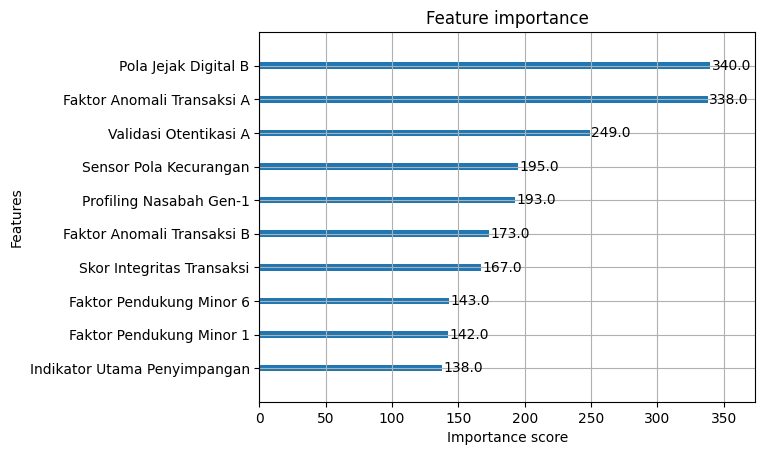

In [5]:
import matplotlib.pyplot as plt

# Mendapatkan skor importance
importance = model.get_booster().get_score(importance_type='weight')
# Mengurutkan
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)

print("Urutan Fitur Paling Berpengaruh:")
for feature, score in sorted_importance:
    print(f"{feature}: {score}")

# Visualisasi
from xgboost import plot_importance
plot_importance(model, max_num_features=10) # Menampilkan 10 teratas
plt.show()

In [6]:
# Prediksi data testing
y_pred = model.predict(X_test)

# Menampilkan hasil evaluasi
print("\n--- Laporan Klasifikasi ---")
print(classification_report(y_test, y_pred))

# Menghitung AUPRC (Area Under the Precision-Recall Curve)
auprc = average_precision_score(y_test, model.predict_proba(X_test)[:, 1])
print(f"Nilai AUPRC: {auprc:.4f}")


--- Laporan Klasifikasi ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.30      0.88      0.45        98

    accuracy                           1.00     56962
   macro avg       0.65      0.94      0.72     56962
weighted avg       1.00      1.00      1.00     56962

Nilai AUPRC: 0.7829


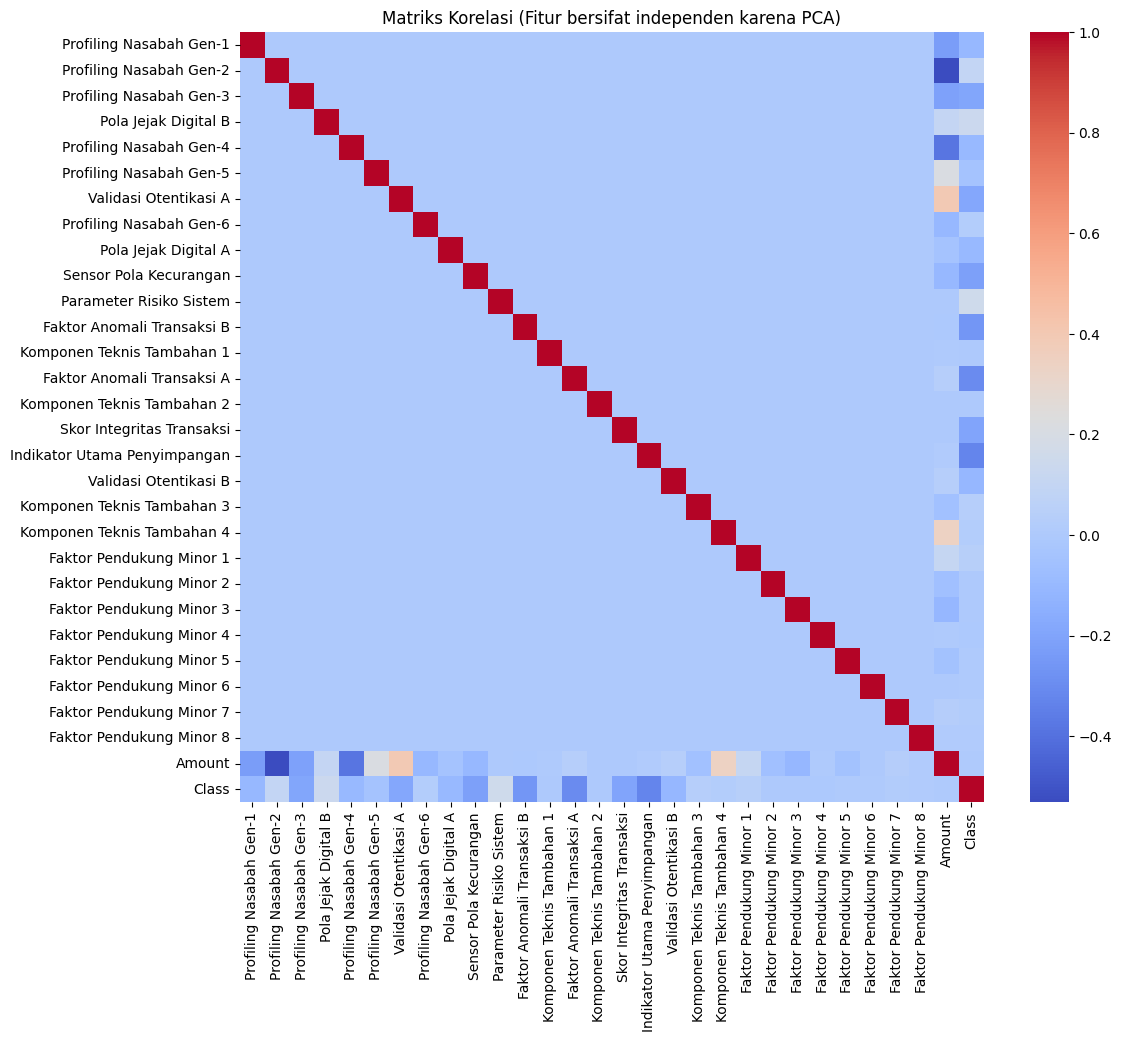

In [8]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Matriks Korelasi (Fitur bersifat independen karena PCA)')
plt.show()

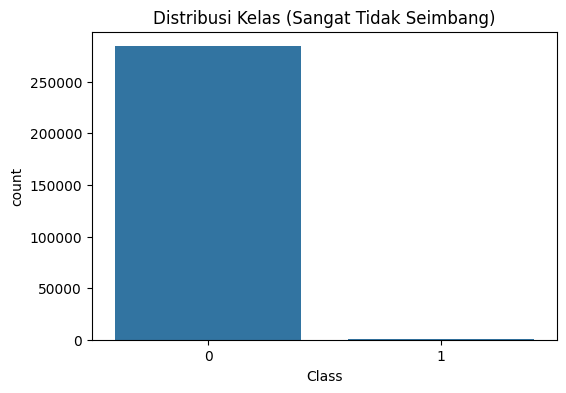

--- EVALUASI MODEL (BAB 4) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.30      0.88      0.45        98

    accuracy                           1.00     56962
   macro avg       0.65      0.94      0.72     56962
weighted avg       1.00      1.00      1.00     56962



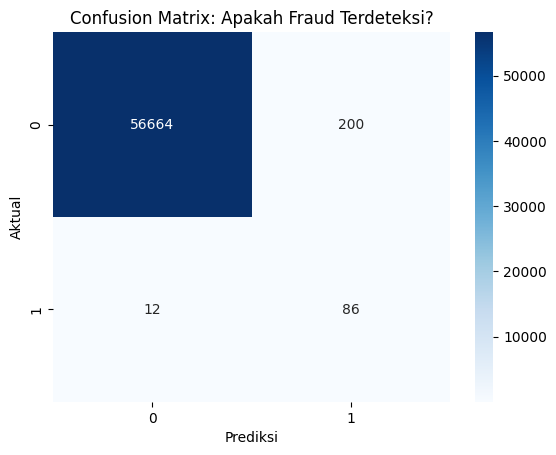

In [9]:
# 1. Visualisasi Imbalance (Untuk Bab 2.2)
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Distribusi Kelas (Sangat Tidak Seimbang)')
plt.show()

# 2. Cetak Hasil Evaluasi (Untuk Bab 4.1)
# Pastikan Anda sudah menjalankan proses SMOTE-ENN dan model.fit sebelumnya
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)
print("--- EVALUASI MODEL (BAB 4) ---")
print(classification_report(y_test, y_pred))

# 3. Visualisasi Confusion Matrix (Untuk Bab 4.1)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix: Apakah Fraud Terdeteksi?')
plt.show()